# Healthcare Insurance Data Analysis

## Project Aim

This project analyses a healthcare insurance dataset obtained from Kaggle to investigate how personal, lifestyle and geographic factors are associated with medical insurance charges.

The analysis focuses on age, sex, BMI, number of children, smoking status, region and insurance charges.

## Objectives

- Investigate and understand the healthcare insurance dataset.
- Prepare and clean the data for analysis.
- Explore the numerical and categorical variables.
- Investigate the distribution of insurance charges.
- Use appropriate data visualisations to explore relationships between insurance charges and other variables.
- Interpret the findings from the analysis and visualisations.
- Summarise the main findings and conclusions.

## Dataset

The dataset used in this project was obtained from Kaggle. It contains information about personal attributes, lifestyle factors and geographic factors in relation to medical insurance charges.

The dataset contains the following variables:

- Age
- Sex
- BMI
- Number of children
- Smoking status
- Region
- Insurance charges

## Inputs

- `insurance.csv` — the healthcare insurance dataset obtained from Kaggle.

## Outputs

- Cleaned and analysed healthcare insurance data.
- Data visualisations showing the distribution of insurance charges and relationships with other variables.
- Interpretations and conclusions based on the analysis.

## Tools and Libraries

The project uses Python and data analysis and visualisation libraries including:

- Pandas for data manipulation and analysis.
- NumPy for numerical operations.
- Matplotlib for data visualisation.
- Seaborn for statistical data visualisation.
- Plotly for interactive visualisations.

# Section 1: Data Investigation, ETL and Data Cleaning

### Pandas version 3.0.5

I imported Pandas because it will be used to load, clean and analyse
the healthcare insurance dataset.

I also checked the installed Pandas version to record the software
environment used for this project.

In [2]:
# Import Pandas for data analysis
import pandas as pd

# Check the installed Pandas version
print(pd.__version__)

3.0.5


### Loading the dataset

I loaded the healthcare insurance CSV file into a Pandas DataFrame
called `df`. A DataFrame organises data into rows and columns,
making it suitable for data exploration and analysis.

In [3]:
# Load the healthcare insurance dataset
df = pd.read_csv("insurance.csv")

### Initial preview of the dataset

The first five rows were displayed using `df.head()` to confirm that
the dataset was loaded successfully. The dataset contains information
about age, sex, BMI, number of children, smoking status, geographic
region and medical insurance charges.

The preview provides an initial understanding of the variables that
will be investigated during the analysis.

In [4]:
# Display the first five rows of the dataset

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Understanding the DataFrame

The `df.info()` method is used to get a summary of the DataFrame. It shows the number of rows and columns, the column names, the number of non-null values, and the data type of each column.

The dataset contains 1,338 rows and 7 columns. All columns have 1,338 non-null values, which means there are no missing values in the dataset.

The data types show that `age` and `children` are integers, `bmi` and `charges` are floating-point numbers, and `sex`, `smoker`, and `region` contain text data.

This initial check helps identify the structure of the dataset and whether there are any missing values or data types that may need to be addressed during data cleaning.


In [5]:
# Display information about the dataset structure and data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


### Checking for Missing Values

Missing values can affect the accuracy of data analysis and may need to be handled before analysing the dataset.

I will check each column for missing values to determine whether any records require further cleaning.

Though df.info() checks and tells about missing data, i am still running the missing value code as the data cleaning process.

The `isnull().sum()` method counts the number of missing values in each column.


In [6]:
# Check for missing values in each column

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

**The result shows that there are no missing values in the dataset, so no missing data needs to be filled or removed.**

### Checking for Duplicate Rows

The `df.duplicated().sum()` method is used to check whether the DataFrame contains any completely duplicated rows.

The result shows that there is 1 duplicate row in the dataset. Identifying duplicate records is an important part of data cleaning because duplicate rows can affect the accuracy of the analysis.


In [7]:
# Check how many duplicate rows are in the data

df.duplicated().sum()

np.int64(1)

### Inspecting the Duplicate Row

The `df[df.duplicated()]` method is used to display the rows that have been identified as duplicates.

This allows me to inspect the duplicated record before deciding whether it should be removed from the dataset.


In [8]:
# Show the actual duplicate rows

df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



### Confirming Duplicate Records

The `df[df.duplicated(keep=False)]` method is used to display all rows that are part of a duplicate, including the original and the duplicated record.

Using `keep=False` allows both identical rows to be displayed so that I can confirm that the records are complete duplicates before deciding whether to remove them.

This provides an additional check before making changes to the dataset.


In [9]:
# Display all rows that are duplicated, including both the original and duplicate rows,
# so we can identify and review duplicate records before removing them.

df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


### Removing the Duplicate Row

The inspection confirms that the records at index 195 and index 581 contain exactly the same values. Therefore, one of the duplicate records can be removed to prevent the duplicate data from affecting the analysis.

The `drop_duplicates()` method is used to remove duplicate rows from the DataFrame.


In [10]:
# Remove duplicate rows from the dataset so each record is represented only once.

df = df.drop_duplicates()

### Verifying Duplicate Removal

After removing the duplicate row, I will check the DataFrame again to confirm that no duplicate rows remain.

The `df.duplicated().sum()` method is used to count the remaining duplicate rows. A result of 0 will confirm that the duplicate has been successfully removed.


In [11]:
# Count the number of duplicate rows to identify repeated records in the dataset.

df.duplicated().sum()

np.int64(0)

In [12]:
# Check the DataFrame shape to confirm how many rows and columns remain after removing duplicates.

df.shape

(1337, 7)

### Dataset Dimensions After Cleaning

The `shape` attribute was used to confirm the number of rows and columns remaining after data cleaning. The dataset contains    1,337 rows and 7 columns after removing the duplicate record.

### Checking Categorical Values

The categorical columns contain text values rather than numerical measurements. I will check the unique values in these columns to identify any unexpected or inconsistent entries that may need cleaning.

This check helps confirm that the values are consistent and suitable for analysis.


In [13]:
# Display the unique values in the sex column to identify the categories present in the dataset.

df['sex'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

 **The sex column contains two consistent values, female and male, so no cleaning is required for this column.**

 **Next I will check the unique values in the smoker column to identify any unexpected or inconsistent entries.**

In [14]:
# Display the unique values in the smoker column to identify the categories present in the dataset.

df['smoker'].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

 **The smoker column contains only yes and no, so no cleaning is required.**

In [15]:
# Display the unique values in the region column to identify the geographical categories present in the dataset.

df['region'].unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

 **The region column contains four consistent values, so no cleaning is required.**

### Note on additional uniqueness checks

I did not use `df['children'].unique()` or `df.nunique()` at this stage. Although these functions could provide additional information about the dataset, they were not necessary for the current data-quality assessment. The range and distribution of the `children` variable were already covered by `df.describe()`, while `df['sex'].unique()`, `df['smoker'].unique()`, and `df['region'].unique()` directly identified the categories needed for checking the categorical variables.

### Checking Age Values

**The `age` column contains numerical values. I will check the minimum and maximum age to identify any values that may be outside a sensible range or require further investigation.This also helps to identify the youngest and oldest individuals included in the insurance data .**


In [16]:
# Check the minimum and maximum age to understand the age range represented in the dataset.

df['age'].min(), df['age'].max()

(np.int64(18), np.int64(64))

**The age values range from 18 to 64, which is a sensible range for the adult insurance dataset,  and no obviously invalid age values were identified. Therefore, no cleaning is required for the age column.**


### Checking BMI Values

**The `bmi` column contains numerical values. I will check the minimum and maximum BMI values to identify any values that may be outside a plausible range or require further investigation.**


In [17]:
# Check the minimum and maximum BMI values to understand the BMI range represented in the dataset.

df['bmi'].min(), df['bmi'].max()

(np.float64(15.96), np.float64(53.13))

 **The BMI values range from 15.96 to 53.13. These are plausible recorded BMI values, so no obviously invalid values were identified and no cleaning is required for the bmi column.**

### Checking Children Values

**The children column contains numerical values. I will check the minimum and maximum number of children to identify any values that may be invalid or require further investigation.**


In [18]:
# Check the minimum and maximum number of children to understand the range of this variable in the dataset.

df['children'].min(), df['children'].max()

(np.int64(0), np.int64(5))


**The number of children ranges from 0 to 5. These are plausible values, so no obviously invalid values were identified and no cleaning is required for the children column.**




### Checking Charges Values

**The `charges` column contains the insurance charges as numerical values. I will check the minimum and maximum charges to identify any values that may be invalid or require further investigation.**


In [19]:
# Check the minimum and maximum insurance charges to understand the range of costs recorded in the dataset.

df['charges'].min(), df['charges'].max()

(np.float64(1121.8739), np.float64(63770.42801))

**The insurance charges range from 1,121.8739 to 63,770.42801. All values are positive, so no obviously invalid values were identified and no cleaning is required for the `charges` column.**



### Descriptive Statistics

df.describe() is a Pandas method for descriptive statistics, it gives a statistical summary of my numerical columns.
Descriptive statistics provide a summary of the numerical columns in the dataset. They help us understand the distribution and general characteristics of variables such as age, BMI, number of children, and insurance charges.


In [20]:
# Generate descriptive statistics for the numerical variables to understand their central tendency, spread, and range.

df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


**The descriptive statistics provide an overview of the numerical variables. After removing the duplicate record, the dataset contains 1,337 records. The summary shows the central values and ranges of age, BMI, children, and insurance charges, which will help guide the next stage of the analysis.**


## Project Purpose and Research Questions

### Project Purpose

The purpose of this project is to analyse healthcare insurance data to identify factors that are associated with differences in insurance charges. The analysis will explore personal, lifestyle and geographic factors such as age, BMI, smoking status, number of children and region.

The findings are intended to help healthcare insurance stakeholders and data analysts better understand patterns in insurance costs and support evidence-based decision-making.

### Target Audience

The primary target audience is healthcare insurance stakeholders and data analysts who may use data-driven insights to understand factors associated with healthcare insurance costs.

### Research Questions

1. What is the distribution of healthcare insurance charges in the dataset?
2. How does smoking status relate to insurance charges?
3. Is there a relationship between BMI and insurance charges?
4. How does age relate to insurance charges?
5. Do insurance charges differ between geographic regions?
6. How are age, BMI, children and insurance charges related to each other?


### Development Challenge: Python Environment and Visualisation Libraries

During the development of this project, I encountered several technical issues when preparing the Python environment for data visualisation.

When I first attempted to create a histogram using Pandas, the notebook reported that Matplotlib was required. Further investigation showed that different Python virtual environments were being used by the development environment.

I also identified an incompatible NumPy installation. The error message showed that compiled NumPy files were built for Python 3.14 while the project was running Python 3.12. This prevented NumPy and dependent libraries from importing correctly.


To resolve these issues, I used the project's Python 3.12 virtual environment and reinstalled the required packages. NumPy, Pandas and Matplotlib were then tested directly in the project environment to confirm that they could be imported successfully. Pillow and kiwisolver, which are dependencies of Matplotlib, also required reinstallation.

These troubleshooting steps improved the reliability of the development environment and demonstrated the process of identifying, investigating and resolving errors rather than ignoring them.

The main data-analysis tools used in this project are Python, Pandas, NumPy and Matplotlib. Additional libraries will be introduced only when they are required for the analysis.

In [21]:

# Display the path of the Python executable currently being used by the notebook.
import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv\Scripts\python.exe


### Python Executable Path
Notebook was initially using this path

Why I checked sys.executable again: 
Troubleshooting the Python environment and needed to confirm the final interpreter being used by the capstone notebook,is using Healthcare_Insurance_capstone.venv,which is the virtual environment I created for this project work.

In [22]:
# Check the Python executable again after changing the environment to confirm which Python interpreter the notebook is using.

import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv\Scripts\python.exe


In [23]:
# Verify the Python executable currently selected for the capstone notebook after changing the project environment to ensure the correct interpreter is being used.

import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv\Scripts\python.exe


### Python Environment Verification

The Python environment was checked several times during the project setup using `sys.executable`. This was necessary because the notebook was using different Python environments during troubleshooting. Checking `sys.executable` allowed me to identify exactly which Python interpreter was being used by the notebook and confirm that the capstone project was connected to the intended environment.

These checks were part of the project setup and troubleshooting process rather than the data analysis itself. They helped ensure that the required Python libraries, including Pandas, NumPy and Matplotlib, were installed and available in the environment being used by the capstone notebook.

In [24]:
import matplotlib
print(matplotlib.__version__)

3.11.1


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Section 2: Data Visualisation and Analysis

## Section Overview

This section uses data visualisation to explore the distribution of healthcare insurance charges and investigate relationships between insurance charges and other variables in the dataset. The visualisations will be used to identify patterns and trends and support the interpretation of the data.

### Matplotlib Visualisation Method Used

The visualisations in this section use different Python data visualisation approaches. The histogram and bar chart below are created using Pandas plotting, which uses Matplotlib as the underlying visualisation library.

| Visualisation | Method Used | Library |

| Histogram | `df['charges'].plot(kind='hist', bins=30)` | Pandas plotting → Matplotlib |
| Bar chart | `df.groupby("smoker")["charges"].mean().plot(kind="bar")` | Pandas plotting → Matplotlib |

These visualisations are used to explore the distribution of insurance charges and compare average insurance charges between smoking-status groups. Further visualisations in this section will use Seaborn and Plotly to demonstrate different visualisation techniques.

### Why a Histogram?

A histogram is used here to show how insurance charges are distributed across all individuals in the dataset. It groups charges into ranges (bins) and shows how many people fall into each range, making it easy to see whether charges are mostly low, high, or spread out evenly, and to spot any skew or outliers in the data.

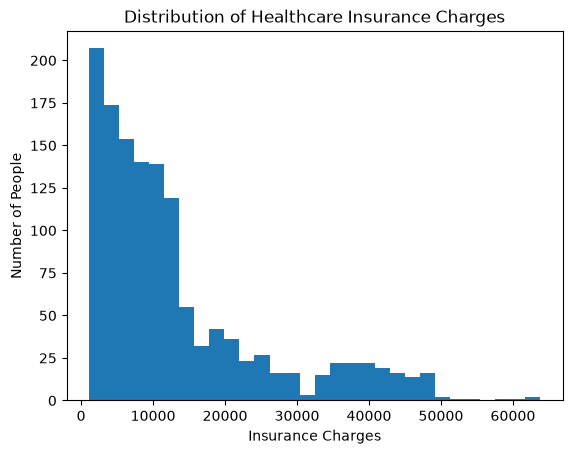

In [26]:

# Create a histogram to examine the distribution and frequency of healthcare insurance charges.
# kind='hist' tells Pandas to create a histogram.
# bins=30 divides the range of insurance charges into 30 intervals (bins) so you can see how frequently charges occur across different ranges.


df["charges"].plot(kind="hist", bins=30)

# Label the x-axis to show the insurance charge values.
plt.xlabel("Insurance Charges")

# Label the y-axis to show the frequency of observations.
plt.ylabel("Number of People")

# Add a descriptive title to the histogram.
plt.title("Distribution of Healthcare Insurance Charges")

# Display the completed histogram.
plt.show()

### Interpretation of Insurance Charge Distribution using Histogram:

The histogram shows that most people in the dataset have relatively low insurance charges.

There are fewer people with higher insurance charges, and only a small number of people have very high charges. This creates a long tail on the right side of the histogram, which means the data is right-skewed.

The high charges are important because they can increase the overall average (mean) insurance charge. Therefore, it is useful to look at both the mean and the median when understanding the typical insurance cost.

### Comparing Average Charges by Smoking Status

I used `groupby()` to separate the data into smokers and non-smokers. I then used `mean()` to calculate the average insurance charge for each group.

This gives us a numerical comparison before creating a **bar chart** to visualise the difference more clearly.

In [27]:

# Find the average insurance charge for smokers and non-smokers.
df.groupby("smoker")["charges"].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

### Initial Finding: Smoking Status and Insurance Charges

The average insurance charge for non-smokers is approximately 8,434, while the average charge for smokers is approximately 32,050.

This shows a substantial difference in average insurance charges between the two groups. The average charge for smokers is approximately 3.8 times higher than for non-smokers.


This is an initial finding rather than evidence that smoking directly causes higher insurance charges. Other variables in the dataset, such as age, BMI, number of children and region, may also influence insurance costs. Further analysis and visualisation will therefore be used to investigate this relationship.

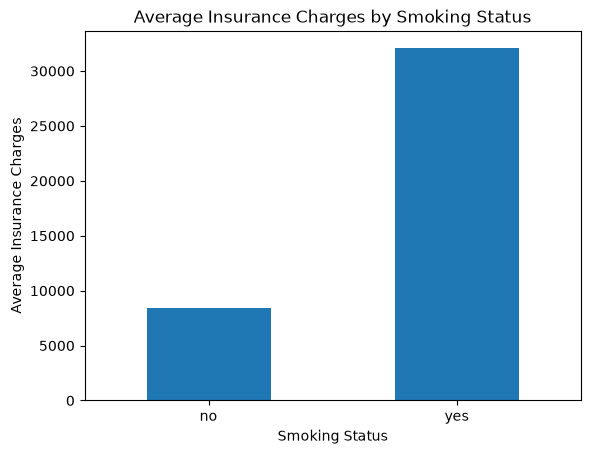

In [28]:

# Calculate the average insurance charges for each smoking-status category and display the results as a bar chart.
# (.plot(kind="bar")turns the two averages into a bar chart)

df.groupby("smoker")["charges"].mean().plot(kind="bar")


# Label the x-axis to identify the smoking-status categories.

plt.xlabel("Smoking Status")

# Label the y-axis to show the average insurance charges.

plt.ylabel("Average Insurance Charges")

# Add a descriptive title to the chart.

plt.title("Average Insurance Charges by Smoking Status")

# Keep the smoking-status labels horizontal for easier reading.

plt.xticks(rotation=0)

# Display the completed bar chart.

plt.show()

### Interpretation of Average Insurance Charges by Smoking Status using Bar Chart:

The bar chart makes the difference between the two groups easier to see. The smoker bar is much higher than the non-smoker bar.

The bar chart shows a large difference in average insurance charges between smokers and non-smokers.

Non-smokers have an average charge of approximately 8,434, while smokers have an average charge of approximately 32,050.

This means that the average insurance charge for smokers is much higher than for non-smokers in this dataset.

This is an important finding for the insurance industry because smoking status appears to be strongly associated with insurance costs. However, this does not prove that smoking is the only reason for the difference, as other factors such as age, BMI and children may also affect insurance charges.

### Seaborn Visualisation Methods Used


Seaborn is a Python visualisation library built on Matplotlib. It provides statistical charts that are useful for exploring distributions, comparisons and relationships within a dataset.

In this section, Seaborn is used to explore the relationship between age and healthcare insurance charges using a scatter plot and to compare the distribution of healthcare insurance charges across different BMI categories using  a box plot.

Age vs Insurance Charges — scatter plot
   

BMI Categories vs Insurance Charges — box plot

 

### Relationship Between Age and Insurance Charges

A scatter plot is used to investigate the relationship between age and insurance charges. Seaborn is used to visualise the individual observations and identify any patterns or trends between age and insurance costs.

In [29]:
# Import visualization libraries
import seaborn as sns          # for statistical plots (heatmaps, distributions, etc.)
import matplotlib.pyplot as plt # for general plotting and chart customization

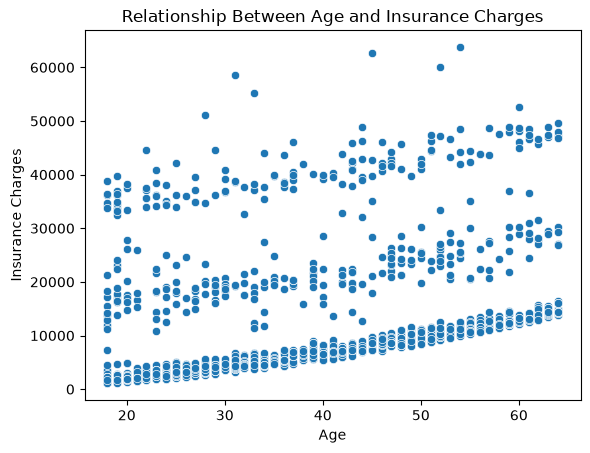

In [30]:


# Create a Seaborn scatter plot to investigate the relationship between age and insurance charges.
sns.scatterplot(data=df, x="age", y="charges")

# Label the x-axis to show the age of the individuals.
plt.xlabel("Age")

# Label the y-axis to show the insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the scatter plot.
plt.title("Relationship Between Age and Insurance Charges")

# Display the completed scatter plot.
plt.show()

### Interpretation of Age and Insurance Charges

The scatter plot shows that insurance charges are widely distributed across different ages. Most observations are concentrated at lower charge levels, while some higher insurance charges occur across the age range.

The relationship between age and insurance charges does not appear to be a simple linear pattern. The wide spread of charges at different ages suggests that other factors in the dataset may also be associated with insurance costs.

This visualisation provides an initial view of the relationship between age and insurance charges, which can be explored further using other variables and visualisations.



### BMI Categories and Insurance Charges

BMI is a numerical variable that can take many different values. To make the comparison easier to interpret, the BMI values are grouped into four standard categories: Underweight, Normal, Overweight and Obese.

A new column called `bmi_category` will be created from the existing `bmi` column. This new categorical variable will then be used to compare insurance charges across the BMI categories.A Seaborn box plot is then used to examine the distribution of insurance charges across the BMI categories.

### Creating the BMI Categories

The `pd.cut()` function is used to divide continuous numerical BMI values into defined ranges. Each range is then given a meaningful category label.

The BMI categories used are:

- Underweight: BMI below 18.5
- Normal: BMI from 18.5 to below 25
- Overweight: BMI from 25 to below 30
- Obese: BMI 30 and above

This creates a new categorical variable called `bmi_category` while keeping the original `bmi` column unchanged.

In [31]:
# Create a new BMI category column by grouping the existing BMI values into defined ranges.
df["bmi_category"] = pd.cut(
    df["bmi"],  # Use the existing BMI values from the DataFrame.
    bins=[0, 18.5, 25, 30, float("inf")],  # Define the boundaries for the four BMI categories.
    labels=["Underweight", "Normal", "Overweight", "Obese"],  # Assign a category label to each BMI range.
    right=False  # Include the lower boundary and exclude the upper boundary of each range.
)

Explaining each code functions:

df["bmi_category"] Creates a new column called bmi_category.

pd.cut() Takes the BMI numbers and puts them into groups/ranges.

df["bmi"] Uses your existing BMI column.

bins Defines where the BMI groups start and finish.

labels Gives each group its name.

right=False Means the lower number belongs to the category, while the upper boundary moves into the next category.

float("inf") Means infinity, so there is no upper limit for the Obese category.

### Checking the New BMI Category Column

The new `bmi_category` column is checked alongside the original BMI values to confirm that the BMI values have been assigned to the appropriate categories.

This is a verification step before creating the visualisation.

In [32]:
# Display the original BMI values and the newly created BMI categories to verify the categorisation.
df[["bmi", "bmi_category"]].head(10)

,bmi,bmi_category
0,27.900,Overweight
1,33.770,Obese
2,33.000,Obese
3,22.705,Normal
4,28.880,Overweight
5,25.740,Overweight
6,33.440,Obese
7,27.740,Overweight
8,29.830,Overweight
9,25.840,Overweight


## Creating BMI Categories

A new `bmi_category` column is created from the numerical BMI values. This derived feature groups individuals into Underweight, Normal, Overweight and Obese categories, making it easier to compare insurance charges across BMI groups.

### Distribution of Insurance Charges by BMI Category

A box plot is used to compare the distribution of insurance charges across the four BMI categories.

The box plot allows the median, spread and potential outliers of insurance charges to be compared between the BMI categories. This provides more information than comparing only the average charge for each category.

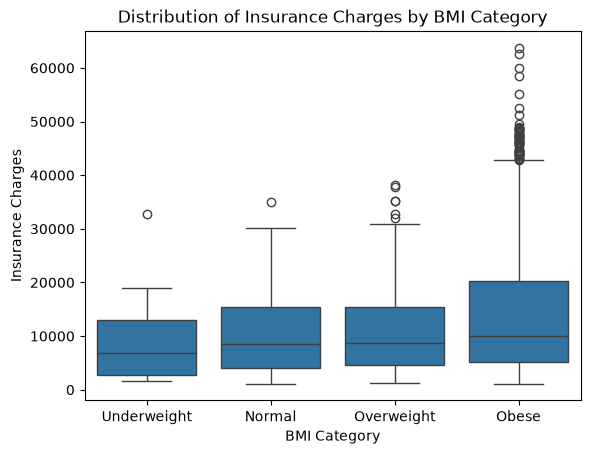

In [33]:
# Create a Seaborn box plot to compare the distribution of insurance charges across BMI categories.
sns.boxplot(data=df, x="bmi_category", y="charges")

# Label the x-axis to identify the BMI categories.
plt.xlabel("BMI Category")

# Label the y-axis to show healthcare insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the box plot.
plt.title("Distribution of Insurance Charges by BMI Category")

# Display the completed box plot.
plt.show()

### Interpretation of BMI Categories and Insurance Charges

The box plot shows some differences in insurance charges across the BMI categories. The underweight category generally shows lower charges, while the obese category shows somewhat higher charges.

The normal-weight and overweight categories have relatively similar distributions. Overall, the differences between the BMI categories appear less pronounced than the differences observed between smokers and non-smokers.

This suggests that BMI may be associated with insurance charges, but other factors are also likely to contribute to the variation in costs.

### Number of Children and Insurance Charges

The number of children is investigated to examine whether insurance charges differ between individuals with different numbers of children.

A Seaborn box plot is used because the `children` variable contains a small number of discrete values (0 to 5). This allows the distribution of insurance charges to be compared for each number of children.

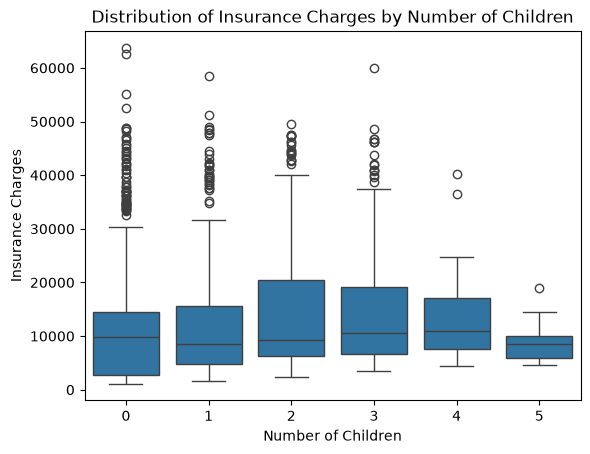

In [34]:
# Create a Seaborn box plot to compare insurance charges for different numbers of children.
sns.boxplot(data=df, x="children", y="charges")

# Label the x-axis to show the number of children.
plt.xlabel("Number of Children")

# Label the y-axis to show healthcare insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the box plot.
plt.title("Distribution of Insurance Charges by Number of Children")

# Display the completed box plot.
plt.show()



### Interpretation of Insurance Charges by Number of Children

2 and 3 children groups: Show the widest spread of charges, with higher medians (around 9,000–10,500).

0 children group: Has the most outliers, including very high charges above 60,000. This is likely because it’s the largest group, so it captures more extreme cases.

4 and 5 children groups: Show smaller ranges and fewer outliers, but this is probably due to having fewer data points rather than truly lower costs.

Overall trend: No clear pattern that charges increase or decrease with more children. Differences are mostly due to group sizes, not the number of children itself.


### Distribution of Individuals by Number of Children

A Seaborn count plot is used to show the number of individuals in each children category.

This visualisation complements the box plot by showing how many observations are available for each group. This is important when interpreting the insurance-charge distributions because groups with very few observations may produce less reliable comparisons.

In [35]:

# Count the number of people in each children category and display the results in numerical order from 0 to 5.

df['children'].value_counts().sort_index()

children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

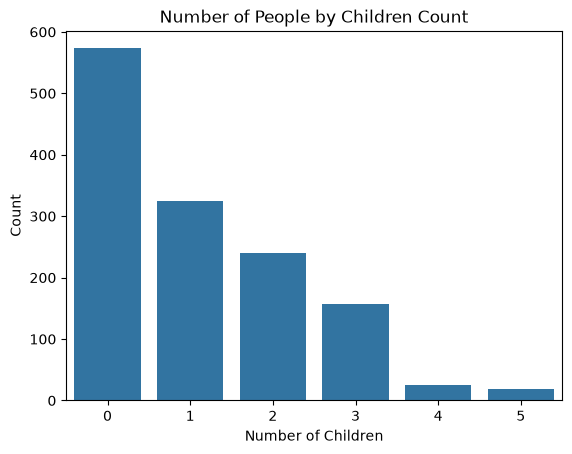

In [36]:
sns.countplot(x="children", data=df)  # Create a Seaborn count plot showing the number of people in each children group.

plt.title("Number of People by Children Count")  # Add a descriptive title to the chart.
plt.xlabel("Number of Children")  # Label the x-axis with the number of children.
plt.ylabel("Count")  # Label the y-axis with the number of people.

plt.show()  # Display the completed count plot.


### Interpretation of Number of People by Children Count

The count plot shows that the dataset contains the largest number of individuals with no children, followed by individuals with one and two children.

The number of individuals decreases as the number of children increases. The groups with four and five children contain very few observations compared with the other groups.

This uneven distribution is important when interpreting the insurance-charge box plot, as conclusions about the smaller groups should be made with caution.

### Why Two Visualisations Are Used

The count plot and box plot provide different information about the `children` variable.

- **Count plot:** shows how many people are in each number-of-children group.
- **Box plot:** shows how insurance charges are distributed within each number-of-children group.

The count plot helps assess the size of each group, while the box plot helps compare insurance charges between the groups. Using both visualisations provides a clearer understanding of the data.

### Sex and Insurance Charges

The sex variable is analysed to investigate whether the distribution of healthcare insurance charges differs between female and male individuals.

A Seaborn box plot is used to compare the distribution, median and spread of insurance charges between the two sex categories. This helps determine whether there is a noticeable difference in insurance charges between females and males.

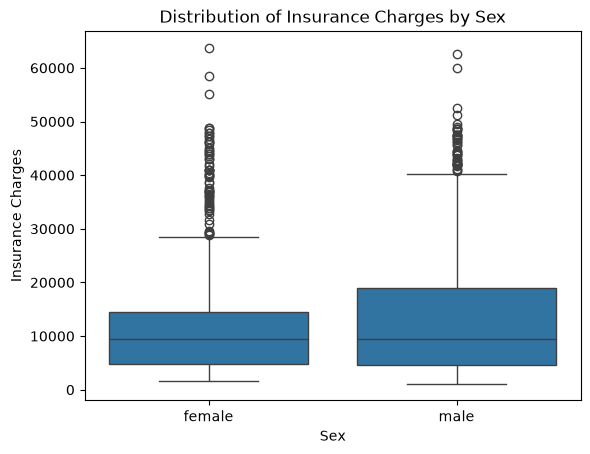

In [37]:
# Create a Seaborn box plot to compare insurance charges between female and male individuals.
sns.boxplot(data=df, x="sex", y="charges")

# Label the x-axis to show the sex categories.
plt.xlabel("Sex")

# Label the y-axis to show healthcare insurance charges.
plt.ylabel("Insurance Charges")

# Add a descriptive title to the chart.
plt.title("Distribution of Insurance Charges by Sex")

# Display the completed box plot.
plt.show()

### Interpretation of Insurance Charges by Sex

The box plot shows some differences in the distribution of insurance charges between female and male individuals. The male group shows a wider spread of charges and extends to higher values than the female group.

However, the two distributions overlap considerably, suggesting that sex alone may not explain the differences in insurance charges. Other factors in the dataset are likely to have a stronger influence on insurance costs.

Overall, sex appears to show some variation in insurance charges, but the relationship does not appear as pronounced as the differences observed for some other variables.

### Matplotlib Visualisation Method Used – Region and Insurance Charges

A bar chart is used to compare the average healthcare insurance charges across the four geographic regions.

The dar chart is created using Pandas plotting with Matplotlib. This visualisation provides a clear comparison of the average charges between regions and supports the geographic analysis of the dataset.

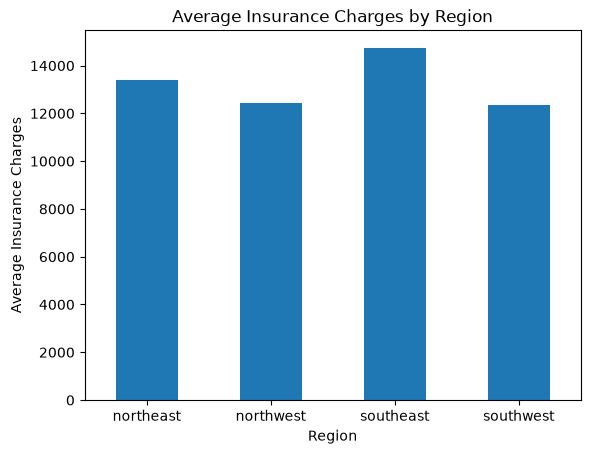

In [38]:
# Calculate the average insurance charges for each region and create a bar chart.
df.groupby("region")["charges"].mean().plot(kind="bar")

# Label the x-axis with the geographic regions.
plt.xlabel("Region")

# Label the y-axis with the average insurance charges.
plt.ylabel("Average Insurance Charges")

# Add a descriptive title to the chart.
plt.title("Average Insurance Charges by Region")

# Keep the region names horizontal for easier reading.
plt.xticks(rotation=0)

# Display the completed bar chart.
plt.show()

### Explaining the use of code:

df.groupby("region") → puts the records into the four region groups.
["charges"] → selects the insurance-charge column.
.mean() → calculates the average charge for each region.
.plot(kind="bar") → displays those averages as a bar chart.
plt.xlabel() → labels the regions.
plt.ylabel() → labels the average charges.
plt.title() → describes what the chart shows.
plt.xticks(rotation=0) → keeps the region names horizontal.
plt.show() → displays the chart

### Interpretation of Average Insurance Charges by Region

The bar chart shows some differences in average insurance charges across the four regions.

The southeast region has the highest average insurance charges, at around 14,000–15,000. The northeast region is around   
13,000–14,000, while the northwest and southwest regions have lower average charges of around 12,000.

Overall, the southeast region shows the highest average insurance charges, while the southwest and northwest show the lowest. This suggests that geographic region may be associated with differences in insurance charges, although other factors may also contribute to these differences.

### Overall Comparison of Insurance Charges

The individual visualisations examined each variable separately against insurance charges. This section brings the findings together by comparing average insurance charges across different groups.

This comparison helps identify which factors show noticeable differences in insurance charges and provides a basis for the later correlation analysis.

### Transition from Descriptive Analysis to Correlation Analysis

The descriptive analysis has examined the healthcare insurance dataset and explored how individual variables are associated with insurance charges.

The visualisations have shown differences in insurance charges across age, BMI, smoking status, number of children, sex and region.

The next stage uses correlation analysis to examine the relationships between the numerical variables and insurance charges. This helps identify which numerical variables have stronger or weaker relationships with insurance charges.

The correlation results will be considered together with the earlier visualisations when drawing the final conclusions.

### Correlation Analysis

Correlation analysis examines the strength and direction of relationships between numerical variables in the dataset.

The analysis focuses on age, BMI, number of children and insurance charges. A correlation coefficient ranges from -1 to +1. A value closer to +1 indicates a stronger positive relationship, while a value closer to -1 indicates a stronger negative relationship. A value close to 0 indicates a weak linear relationship.

Correlation does not prove that one variable causes another.


 ### How the below code works:
df[["age", "bmi", "children", "charges"]]  selects the numerical variables.
.corr()  calculates the correlation between each pair of numerical variables.
correlation_matrix stores the results.
The final line displays the correlation table.

In [39]:
# Select the numerical variables and calculate their correlation coefficients.
correlation_matrix = df[["age", "bmi", "children", "charges"]].corr()

# Display the correlation matrix.
correlation_matrix

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


### Interpretation of Correlation Analysis

The correlation analysis shows that age has the strongest positive relationship with insurance charges among the numerical variables, with a correlation of approximately 0.30.

BMI has a weaker positive relationship with insurance charges, with a correlation of approximately 0.20.

The number of children has a very weak positive relationship with insurance charges, at approximately 0.07.

Overall, age shows the strongest linear relationship with insurance charges among these numerical variables. However, the correlations are not strong, showing that these variables alone do not fully explain differences in insurance charges.

The relationships between age, BMI and children are also relatively weak, indicating little linear relationship between these variables.

### Seaborn Visualisation Method Used – Correlation Analysis

Seaborn is used to create a correlation heatmap to visually represent the relationships between the numerical variables in the dataset.

The heatmap makes it easier to identify the strength and direction of relationships between age, BMI, children and insurance charges.

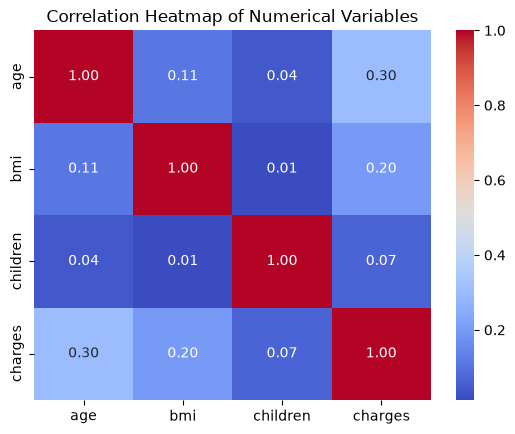

In [40]:
# Create a Seaborn heatmap to visually display the correlation matrix.
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Add a title to the heatmap.
plt.title("Correlation Heatmap of Numerical Variables")

# Display the heatmap.
plt.show()

### Explaining the Code

The `sns.heatmap()` function displays the correlation matrix as a colour-coded heatmap.

`annot=True` displays the correlation values inside the cells.

`fmt=".2f"` formats the displayed values to two decimal places.

The heatmap makes stronger and weaker relationships easier to identify visually.

`plt.title()` adds a descriptive title, and `plt.show()` displays the completed chart.

### Interpretation of the Correlation Heatmap

The correlation heatmap shows the strength and direction of relationships between the numerical variables.

Age has the strongest positive correlation with insurance charges among the numerical variables, at approximately 0.30. BMI has a weaker positive correlation of approximately 0.20, while the number of children has a very weak positive correlation of approximately 0.07.

Overall, the heatmap confirms that age has the strongest linear relationship with insurance charges among these numerical variables. However, the relationships are not strong enough to explain insurance charges on their own. Other factors, particularly categorical variables such as smoking status, also need to be considered when interpreting the overall findings.

### Plotly Visualisation Method Used

Plotly is used to create an interactive visualisation of age and insurance charges, with smoking status represented by colour.

The interactive chart allows the relationship between age and insurance charges to be explored while distinguishing between smokers and non-smokers.

This provides an additional view of the data and helps investigate whether smoking status is associated with the different levels of insurance charges observed across ages.

In [41]:
# Verify the Python interpreter being used by the notebook.
import sys
print(sys.executable)

c:\Users\kavit\OneDrive\Desktop\Healthcare_Insurance_Capstone\.venv\Scripts\python.exe


In [42]:
# Check that nbformat is installed and available.
import nbformat
print(nbformat.__version__)

5.11.1


In [43]:
# Import Plotly Express for creating interactive visualisations.
import plotly.express as px

# Create an interactive scatter plot showing age and insurance charges,
# with smoking status represented by colour.
fig = px.scatter(
    df,
    x="age",
    y="charges",
    color="smoker",
    title="Age and Insurance Charges by Smoking Status",
    labels={
        "age": "Age",
        "charges": "Insurance Charges",
        "smoker": "Smoking Status"
    }
)
# Save the interactive Plotly chart as an HTML file.
fig.write_html("age_insurance_smoking_plot.html")

# Display the interactive Plotly chart in the web browser.
fig.show()


### Interpretation of the Plotly Visualisation

The chart shows a clear difference between smokers and non-smokers.

Non-smokers form a relatively tight band of insurance charges, generally increasing gradually as age increases. Smokers show much higher insurance charges, with many points forming higher clusters across different ages.

The chart also shows that some younger smokers have higher insurance charges than older non-smokers. Age still shows a gradual upward pattern within the groups, but smoking status appears to have a stronger association with insurance charges than age alone.

** Smoking status appears to be one of the strongest factors associated with differences in insurance charges in this dataset.**


## Overall Comparison of Insurance Charges by Key Factors

## Overall Comparison of Variables

The descriptive analysis has examined the relationship between insurance charges and each main variable individually.

The next stage compares the average insurance charges across the categorical variables to identify which factors show the largest differences in insurance costs.

This comparison helps determine which variables appear to have the strongest association with insurance charges in this dataset.

In [44]:
# Calculate the average insurance charges for smokers and non-smokers.
average_charges_smoker = df.groupby('smoker')['charges'].mean()

# Display the average insurance charges for each smoking-status group.
average_charges_smoker

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

### Explaining the Code

The `groupby()` function groups the data according to smoking status.

The `charges` column is then selected and `.mean()` calculates the average insurance charge for each group.

This allows the average insurance charges for smokers and non-smokers to be compared directly.

In [45]:
# Calculate the average insurance charges for each sex.
average_charges_sex = df.groupby('sex')['charges'].mean()

# Calculate the average insurance charges for each region.
average_charges_region = df.groupby('region')['charges'].mean()

# Calculate the average insurance charges for each number of children.
average_charges_children = df.groupby('children')['charges'].mean()

# Display the average charges for each categorical variable.
print("Average insurance charges by sex:")
print(average_charges_sex)

print("\nAverage insurance charges by region:")
print(average_charges_region)

print("\nAverage insurance charges by number of children:")
print(average_charges_children)

Average insurance charges by sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

Average insurance charges by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Average insurance charges by number of children:
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


### Explaining the Code

The `groupby()` function groups the dataset according to each categorical variable.

The `charges` column is selected and `.mean()` calculates the average insurance charge within each group.

The code calculates average insurance charges by sex, region, and number of children. These results provide numerical comparisons between the groups and help identify which categorical variables show larger differences in average insurance charges.

This comparison complements the earlier visualisations by providing numerical evidence for the differences observed between groups.

## Comparing Average Insurance Charges Across Key Factors

The average insurance charges calculated for smoking status, sex, region and number of children provide a numerical comparison of the differences between groups.

This comparison helps identify which categorical variables show the largest differences in average insurance charges. The results will be considered together with the earlier visualisations and correlation analysis when drawing the final conclusions.

## Final Findings: Factors Associated with Insurance Charges

The exploratory data analysis examined age, BMI, smoking status, sex, region and number of children in relation to healthcare insurance charges.

The results indicate that **smoking status shows the strongest difference in insurance charges**. The average charge for smokers is approximately 32,050, compared with approximately 8,441 for non-smokers.

**Age** shows a moderate positive correlation with insurance charges (approximately 0.30), indicating that charges tend to increase as age increases.

**BMI** shows a weaker positive correlation with insurance charges (approximately 0.20), suggesting that higher BMI is associated with somewhat higher charges, although the relationship is weaker than age.

**Region** shows some differences in average insurance charges. The Southeast has the highest average charge, while the Southwest has the lowest. However, these differences are considerably smaller than the difference observed between smokers and non-smokers.

**Sex** shows a relatively small difference in average charges, with males having higher average charges than females.

**Number of children** does not show a consistent pattern of increasing insurance charges as the number of children increases. Therefore, the number of children appears to have a weaker and less consistent association with charges in this dataset.

Overall, the analysis suggests that **smoking status is the most prominent factor associated with differences in healthcare insurance charges**, followed by age and BMI. Region and sex show smaller differences, while the number of children does not show a clear consistent relationship.

These findings are based on exploratory analysis and describe associations within this dataset; they do not establish that any individual factor directly causes higher insurance charges.

## Hypothesis

The analysis hypothesises that lifestyle and personal factors, particularly smoking status, age and BMI, are associated with differences in healthcare insurance charges.

It is expected that smokers will have higher insurance charges than non-smokers, while older age and higher BMI will also be associated with higher charges.

The exploratory analysis will be used to assess whether the observed results support this hypothesis.

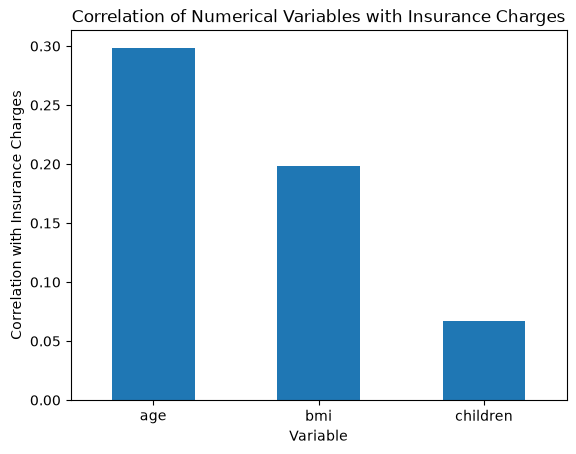

In [46]:
# Select the correlations between the numerical variables and insurance charges.
correlation_with_charges = df[['age', 'bmi', 'children', 'charges']].corr()['charges'].drop('charges')

# Create a bar chart to compare the numerical correlations with insurance charges.
correlation_with_charges.plot(kind='bar')

# Add labels and a title to the chart.
plt.title("Correlation of Numerical Variables with Insurance Charges")
plt.xlabel("Variable")
plt.ylabel("Correlation with Insurance Charges")
plt.xticks(rotation=0)
plt.show()

## Comparison of Numerical Variables

The correlation values are visualised to compare the strength of the linear relationship between age, BMI, number of children and insurance charges.

This chart provides a direct comparison of the numerical variables and complements the earlier scatter plots and correlation heatmap.

### Interpretation of the Correlation Comparison

Age shows the strongest positive correlation with insurance charges among the numerical variables, at approximately 0.30.

BMI shows a weaker positive correlation of approximately 0.20, while the number of children has a very weak positive correlation of approximately 0.07.

This indicates that age has the strongest linear relationship with insurance charges among these numerical variables, although the correlations are not strong enough to explain insurance charges on their own.

The earlier analysis of smoking status provides additional evidence that smoking status shows a much larger difference in average insurance charges than the numerical variables considered here.

## Overall Comparison of Insurance Charges

The analysis now compares the average insurance charges across the main categorical factors: smoking status, sex, region and number of children.

This comparison brings together the findings from the individual visualisations and provides numerical evidence of which groups show the largest differences in insurance charges.

The results are considered alongside the numerical analysis of age and BMI to provide an overall view of the factors associated with insurance charges.


In [47]:
# Calculate average insurance charges for the main categorical and discrete variables.

average_charges_smoker = df.groupby('smoker')['charges'].mean()
average_charges_sex = df.groupby('sex')['charges'].mean()
average_charges_region = df.groupby('region')['charges'].mean()
average_charges_children = df.groupby('children')['charges'].mean()

print("Average insurance charges by smoking status:")
print(average_charges_smoker)

print("\nAverage insurance charges by sex:")
print(average_charges_sex)

print("\nAverage insurance charges by region:")
print(average_charges_region)

print("\nAverage insurance charges by number of children:")
print(average_charges_children)

Average insurance charges by smoking status:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Average insurance charges by sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64

Average insurance charges by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Average insurance charges by number of children:
children
0    12384.695344
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges, dtype: float64


### Explaining the Code

The `groupby()` function groups the data according to each selected variable.

The `charges` column is then selected and the `mean()` function calculates the average insurance charge for each group.

The results provide numerical comparisons for smoking status, sex, region and number of children. These values are used alongside the earlier visualisations and numerical correlation analysis to identify the factors showing the largest differences in insurance charges.


### Interpretation of the Overall Comparison

Smoking status shows the largest difference in average insurance charges. Smokers have an average charge of approximately 32,050, compared with approximately 8,441 for non-smokers.

For sex, the average charge is approximately 13,975 for males and 12,570 for females, showing a relatively smaller difference.

For region, the Southeast has the highest average charge at approximately 14,735, while the Southwest has the lowest at approximately 12,347. This indicates some regional variation, but the difference is much smaller than the difference associated with smoking status.

The average charges by number of children vary between groups and do not show a consistent increasing pattern. Therefore, the number of children does not appear to have a clear relationship with insurance charges in this dataset.

Overall, the comparison supports the earlier visualisations and indicates that smoking status is the most prominent factor associated with differences in insurance charges. Age and BMI also show positive relationships with charges based on the correlation analysis.


## Hypothesis Result

The analysis provides evidence that supports the hypothesis that personal and lifestyle factors are associated with differences in healthcare insurance charges.

Smoking status shows the largest difference, with smokers having substantially higher average insurance charges than non-smokers.

Age and BMI also show positive relationships with insurance charges, although their correlations are weaker than the difference observed for smoking status.

Sex and region show smaller differences in average charges, while the number of children does not show a clear or consistent relationship with insurance charges.

Therefore, the findings support the hypothesis overall, while also showing that different factors have different strengths of association with insurance charges. These findings describe relationships within the dataset and do not establish causation.


# Final Conclusion

The analysis shows that several personal and lifestyle factors are associated with differences in healthcare insurance charges.

Smoking status has the strongest observed difference, with smokers having substantially higher average insurance charges than non-smokers. Age also shows a positive relationship with charges, while BMI has a weaker positive relationship.

Differences in insurance charges are also observed across sex and region, although these differences are smaller. The number of children does not show a clear or consistent relationship with insurance charges in this dataset.

Overall, the exploratory analysis indicates that smoking status is the most prominent factor associated with insurance charges, followed by age and BMI. These findings demonstrate how healthcare insurance data can be analysed to identify patterns in costs and support further investigation.

The findings represent associations within this dataset and should not be interpreted as proof that any individual factor directly causes higher insurance charges. Further analysis and predictive modelling could be used to investigate these relationships in greater depth.


## Healthcare Insurance Applications and AI Opportunity

### Applications of Analytics in Healthcare Insurance

Healthcare insurance analytics can be used to identify patterns in insurance costs, understand differences between customer groups and support data-informed decision-making.

In this project, the analysis identifies smoking status as the most prominent factor associated with higher insurance charges, while age and BMI also show positive relationships with charges. These insights could help insurers understand cost patterns and identify areas for further investigation.

Analytics can also support healthcare insurers by helping them monitor claims and costs, identify unusual patterns, understand customer segments and improve forecasting and planning.

### Challenge and AI Opportunity

A key challenge for healthcare insurers is understanding and predicting which factors are associated with higher insurance costs across different customer groups.

AI and predictive analytics could provide an opportunity to build models that estimate future insurance charges using factors such as age, BMI, smoking status, sex, region and number of children.

Such models could support cost forecasting, risk assessment and more informed decision-making. However, predictive results should be evaluated carefully and used responsibly, particularly where personal and health-related information is involved.

The exploratory analysis in this project provides a foundation for future predictive modelling by identifying important variables and relationships within the dataset.
